<a href="https://colab.research.google.com/github/jesmithamylavarapu-code/neuro_ps1/blob/main/ps1img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:

# Cell 1 — clone only the folder you need (sparse checkout, fast & light)

#download the github repository
!git clone --filter=blob:none --no-checkout --depth 1 https://github.com/Horea94/Fruit-Images-Dataset.git

#moves the downloaded repository to floder so that the next command will excute
%cd Fruit-Images-Dataset

#the repository contains the full dataset we dont need it so it will pick only specific folder
!git sparse-checkout init --cone

#telling the git that we only want the traning data not testing or other data
!git sparse-checkout set Training

#know doowload the file
!git checkout

#going to the main working folder
%cd ..

fatal: destination path 'Fruit-Images-Dataset' already exists and is not an empty directory.
/content/Fruit-Images-Dataset
Your branch is up to date with 'origin/master'.
/content


In [34]:
# Cell 2 — See all the fruit names available in the dataset, so you can pick one

# This lets us use file/folder related commands in Python
import os

# This is the path to the folder that contains one sub-folder per fruit type
training_path = "Fruit-Images-Dataset/Training"

# Look inside that folder and get the names of every fruit folder,
# then arrange them alphabetically so they're easier to scan
fruit_folders = sorted(os.listdir(training_path))

# Print out the full list on screen — look through it and copy the exact
# fruit name you want (spelling and capital letters must match exactly)
print(fruit_folders)

['Apple Braeburn', 'Apple Crimson Snow', 'Apple Golden 1', 'Apple Golden 2', 'Apple Golden 3', 'Apple Granny Smith', 'Apple Pink Lady', 'Apple Red 1', 'Apple Red 2', 'Apple Red 3', 'Apple Red Delicious', 'Apple Red Yellow 1', 'Apple Red Yellow 2', 'Apricot', 'Avocado', 'Avocado ripe', 'Banana', 'Banana Lady Finger', 'Banana Red', 'Beetroot', 'Blueberry', 'Cactus fruit', 'Cantaloupe 1', 'Cantaloupe 2', 'Carambula', 'Cauliflower', 'Cherry 1', 'Cherry 2', 'Cherry Rainier', 'Cherry Wax Black', 'Cherry Wax Red', 'Cherry Wax Yellow', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Corn Husk', 'Cucumber Ripe', 'Cucumber Ripe 2', 'Dates', 'Eggplant', 'Fig', 'Ginger Root', 'Granadilla', 'Grape Blue', 'Grape Pink', 'Grape White', 'Grape White 2', 'Grape White 3', 'Grape White 4', 'Grapefruit Pink', 'Grapefruit White', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Lemon Meyer', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mango Red', 'Mangostan', 'Maracuja', 'Melo

In [35]:
# Cell 3 — pull 18 images of your chosen fruit into a clean 'combined' folder

# These let us work with files/folders, pick random items, and copy files
import os, random, shutil

# Search through all the fruit folder names and keep only the ones
# that contain the word "guava" (this handles capital/small letter differences)
matches = [f for f in fruit_folders if "guava" in f.lower()]

# Show which matching folder names were found, just to double-check
print("Matching folders found:", matches)

# Pick the first matching folder name from the list above as our chosen fruit
fruit_name = matches[0]

# Build the full path to that fruit's folder inside the dataset
src = os.path.join(training_path, fruit_name)

# Create a new folder called "combined" to store our selected images
# (if it already exists, don't throw an error, just continue)
os.makedirs("combined", exist_ok=True)

# Go through anything already inside "combined" from a previous run
# and delete it, so old images don't get mixed with the new ones
for f in os.listdir("combined"):
    os.remove(os.path.join("combined", f))

# Get the names of every image file inside the chosen fruit's folder
all_files = os.listdir(src)

# Randomly select 18 images from that list
# (or fewer, if the folder somehow has less than 18 images)
chosen = random.sample(all_files, min(18, len(all_files)))

# Copy each chosen image into the "combined" folder,
# renaming them one by one as fruit_0.jpg, fruit_1.jpg, and so on
for i, f in enumerate(chosen):
    shutil.copy(os.path.join(src, f), f"combined/fruit_{i}.jpg")

# Print a summary showing which fruit was used and how many images were copied
print(f"Using folder: {fruit_name}")
print(f"Copied {len(chosen)} images into 'combined/'")

Matching folders found: ['Guava']
Using folder: Guava
Copied 18 images into 'combined/'


Dataset shape: (18, 224, 224, 3)


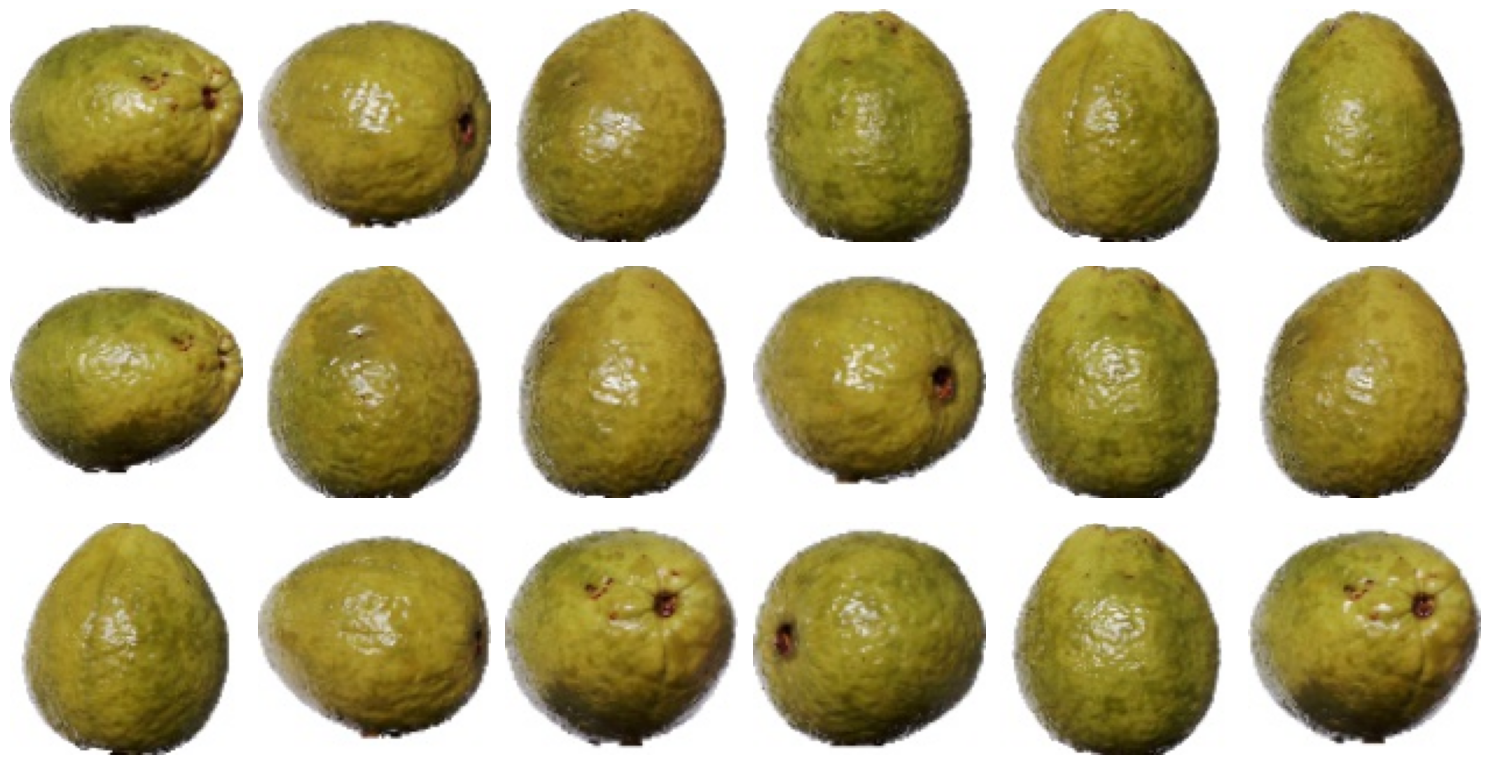

In [41]:
# Cell 4 — preprocessing: resize, normalize, visualize (same as before)

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import glob

# Set the fixed width and height every image will be resized to
TARGET_SIZE = (224, 224)

# Get the file paths of every image inside the "combined" folder
image_paths = glob.glob("combined/*.jpg")

# Create an empty list to store the processed image data
arrays = []

for p in image_paths:
    # Open the image, convert to RGB, and resize so every image is the same size
    img = Image.open(p).convert("RGB").resize(TARGET_SIZE)
    # Convert to numbers and scale from 0-255 down to 0-1
    arr = np.asarray(img).astype("float32") / 255.0
    arrays.append(arr)

# Combine all individual image arrays into one single array
dataset = np.stack(arrays)

# Save the final processed data to a file for reuse later
np.save("preprocessed_dataset.npy", dataset)

print("Dataset shape:", dataset.shape)

# Set up a 3x6 grid to display multiple images at once
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

for ax, p in zip(axes.flatten(), image_paths):
    ax.imshow(Image.open(p))
    ax.axis("off")

plt.tight_layout()
plt.show()

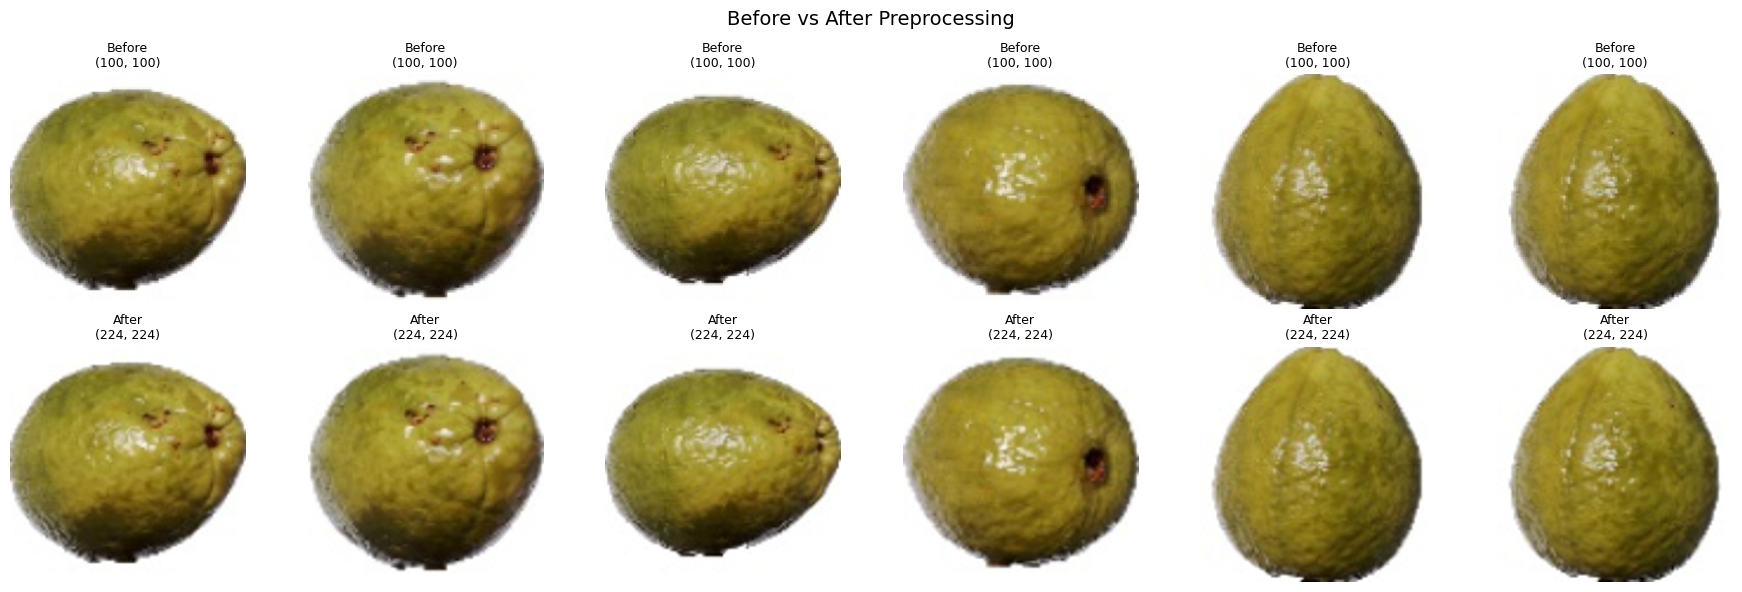

In [45]:
# Cell 5 — show BEFORE (raw) vs AFTER (preprocessed) side by side

from PIL import Image
import matplotlib.pyplot as plt
import glob

# Set the fixed size we resize images to during preprocessing
TARGET_SIZE = (224, 224)

# Get the first 6 image file paths from the "combined" folder, to keep the display simple
image_paths = sorted(glob.glob("combined/*.jpg"))[:6]

# Set up a grid with 2 rows (top = before, bottom = after) and one column per image
fig, axes = plt.subplots(2, len(image_paths), figsize=(3 * len(image_paths), 6))

# Go through each image one at a time, keeping track of its position (i) in the grid
for i, p in enumerate(image_paths):
    # Open the original image exactly as it was downloaded, no changes yet
    original = Image.open(p).convert("RGB")
    # Create the "after" version by resizing it, same as we did in Cell 4
    preprocessed = original.resize(TARGET_SIZE)

    # Build the text for the "before" title, showing the image's original size
    before_title = "Before\n" + str(original.size)
    # Build the text for the "after" title, showing the resized image's size
    after_title = "After\n" + str(preprocessed.size)

    # Show the original image in the top row, at this image's column position
    axes[0, i].imshow(original)
    # Add the "before" title above it
    axes[0, i].set_title(before_title, fontsize=9)
    # Hide the axis lines/numbers since we only want to see the picture
    axes[0, i].axis("off")

    # Show the resized image in the bottom row, same column position
    axes[1, i].imshow(preprocessed)
    # Add the "after" title above it
    axes[1, i].set_title(after_title, fontsize=9)
    # Hide the axis lines/numbers here too
    axes[1, i].axis("off")

# Add one big title above the whole grid describing what it shows
plt.suptitle("Before vs After Preprocessing", fontsize=14)
# Adjust spacing so titles and images don't overlap
plt.tight_layout()
# Actually display the finished before/after grid on screen
plt.show()